In [3]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
best_model = joblib.load("../data/best_sentiment_model.joblib")
vectorizer = joblib.load("../data/tfidf_vectorizer.joblib")
le = joblib.load("../data/label_encoder.joblib")

X_test = sparse.load_npz("../data/X_test.npz")
y_test = pd.read_csv("../data/y_test.csv")["label"]

print("Model:", type(best_model).__name__)
print("Test set shape:", X_test.shape)

Model: LinearSVC
Test set shape: (18096, 40000)


In [5]:
preds = best_model.predict(X_test)
print(classification_report(y_test, preds, target_names=le.classes_))

              precision    recall  f1-score   support

    Negative       0.68      0.71      0.69      6480
     Neutral       0.62      0.64      0.63      5680
    Positive       0.77      0.70      0.73      5936

    accuracy                           0.68     18096
   macro avg       0.69      0.68      0.68     18096
weighted avg       0.69      0.68      0.68     18096



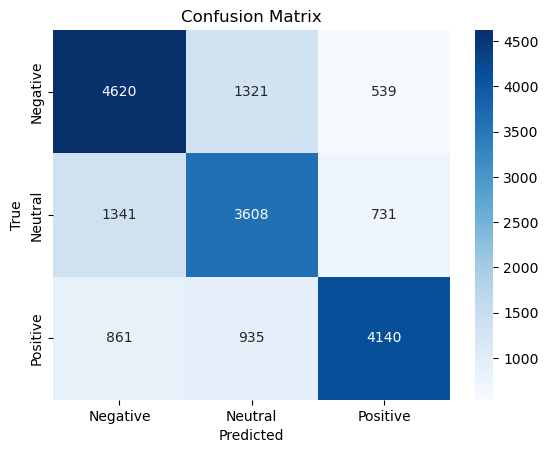

In [6]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

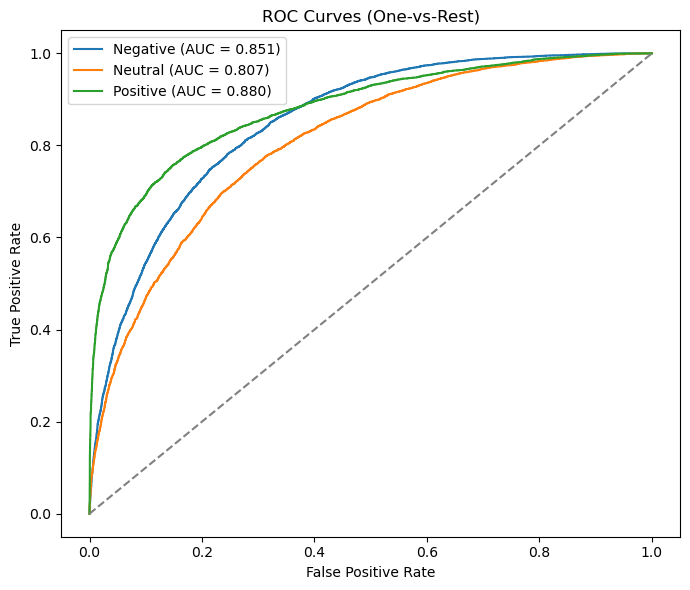

Macro ROC-AUC: 0.8461


In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_test_bin = label_binarize(y_test, classes=sorted(y_test.unique()))
n_classes = y_test_bin.shape[1]

if hasattr(best_model, "predict_proba"):
    scores = best_model.predict_proba(X_test)
elif hasattr(best_model, "decision_function"):
    scores = best_model.decision_function(X_test)
else:
    scores = None

if scores is not None:
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(7, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    macro_auc = roc_auc_score(y_test_bin, scores, average="macro", multi_class="ovr")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
else:
    print("Model exposes neither predict_proba nor decision_function — skipping ROC-AUC.")